# BÀI TẬP: TITANIC
**Nguồn:** kaggle.com/c/titanic (891 dòng)


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [2]:
# TODO
print(df.size)
df.columns
df.dtypes

13365


survived         int64
pclass           int64
sex             object
age            float64
sibsp            int64
parch            int64
fare           float64
embarked        object
class           object
who             object
adult_male        bool
deck            object
embark_town     object
alive           object
alone             bool
dtype: object

## A.2. Missing values & Duplicate data

In [3]:
# TODO
print(df.isnull().sum())
print(df.duplicated().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
107


## A.3. Invalid values

In [4]:
# TODO
dk=df['age']<0
print("số giá trị sai tuổi tác",dk.sum())
dp=df['sex'].isin(['male','female'])
print("số giá trị sai giới tính",df['sex'].size-dp.sum())
dl=df['fare']<0
print("số fare bé hơn 0: ",dl.sum())
dc=df['survived']<0
print('số giá trị sai survived:',dc.sum())

số giá trị sai tuổi tác 0
số giá trị sai giới tính 0
số fare bé hơn 0:  0
số giá trị sai survived: 0


## A.4. Create a new column
Tạo cột `family_size` = sibsp + parch + 1.

In [5]:
# TODO
df['family_size']=df['sibsp'] + df['parch'] + 1

---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [6]:
# TODO
for col in ['age', 'fare', 'family_size']:
    print(col, '| mean:', df[col].mean(), '| median:', df[col].median(), '| mode:', df[col].mode()[0])

age | mean: 29.69911764705882 | median: 28.0 | mode: 24.0
fare | mean: 32.204207968574636 | median: 14.4542 | mode: 8.05
family_size | mean: 1.904601571268238 | median: 1.0 | mode: 1


## Group 2 — Dispersion

In [7]:
# TODO
for col in ['age', 'fare', 'family_size']:
    print(col, '| std:', df[col].std(), '| var:', df[col].var(),
          '| range:', df[col].max()-df[col].min(),
          '| IQR:', df[col].quantile(0.75)-df[col].quantile(0.25))

age | std: 14.526497332334042 | var: 211.01912474630802 | range: 79.58 | IQR: 17.875
fare | std: 49.6934285971809 | var: 2469.436845743116 | range: 512.3292 | IQR: 23.0896
family_size | std: 1.6134585413550873 | var: 2.603248464671686 | range: 10 | IQR: 1.0


## Group 3 — Location and Shape

age | skewness: 0.38910778230082704 | kurtosis: 0.17827415364210353
0.25    20.125
0.50    28.000
0.75    38.000
Name: age, dtype: float64
fare | skewness: 4.787316519674893 | kurtosis: 33.39814088089868
0.25     7.9104
0.50    14.4542
0.75    31.0000
Name: fare, dtype: float64


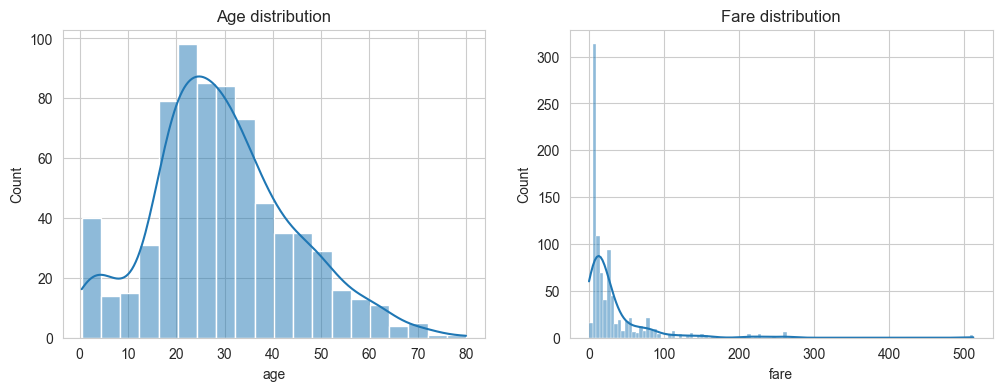

In [8]:
# TODO
for col in ['age', 'fare']:
    print(col, '| skewness:', df[col].skew(), '| kurtosis:', df[col].kurt())
    print(df[col].quantile([0.25, 0.5, 0.75]))

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['age'].dropna(), kde=True, ax=axes[0]).set_title('Age distribution')
sns.histplot(df['fare'], kde=True, ax=axes[1]).set_title('Fare distribution')
plt.show()

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Hạng vé nào có tỷ lệ sống sót cao nhất, chênh lệch bao nhiêu so với hạng thấp nhất?

age | skewness: 0.38910778230082704 | kurtosis: 0.17827415364210353
0.25    20.125
0.50    28.000
0.75    38.000
Name: age, dtype: float64
fare | skewness: 4.787316519674893 | kurtosis: 33.39814088089868
0.25     7.9104
0.50    14.4542
0.75    31.0000
Name: fare, dtype: float64


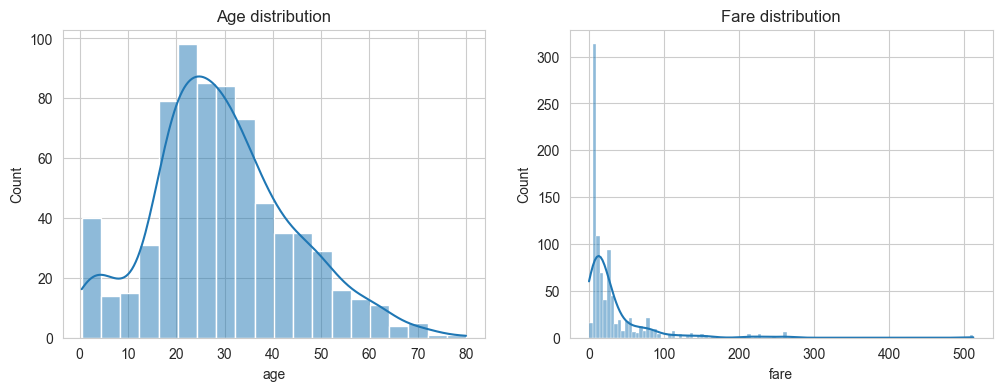

In [9]:
# TODO
for col in ['age', 'fare']:
    print(col, '| skewness:', df[col].skew(), '| kurtosis:', df[col].kurt())
    print(df[col].quantile([0.25, 0.5, 0.75]))
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['age'].dropna(), kde=True, ax=axes[0]).set_title('Age distribution')
sns.histplot(df['fare'], kde=True, ax=axes[1]).set_title('Fare distribution')
plt.show()

## Câu hỏi 2: Giới tính hay hạng vé ảnh hưởng đến sống sót mạnh hơn?

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64
pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


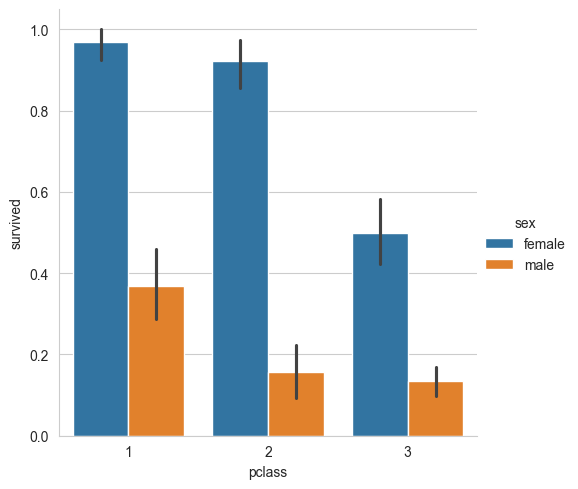

In [10]:
# TODO
print(df.groupby('sex')['survived'].mean())
print(df.groupby('pclass')['survived'].mean())
sns.catplot(x='pclass', y='survived', hue='sex', kind='bar', data=df)

## Câu hỏi 3: Vé đắt hơn có thực sự sống sót cao hơn không?

TtestResult(statistic=np.float64(-7.939191660871055), pvalue=np.float64(6.120189341924198e-15), df=np.float64(889.0))

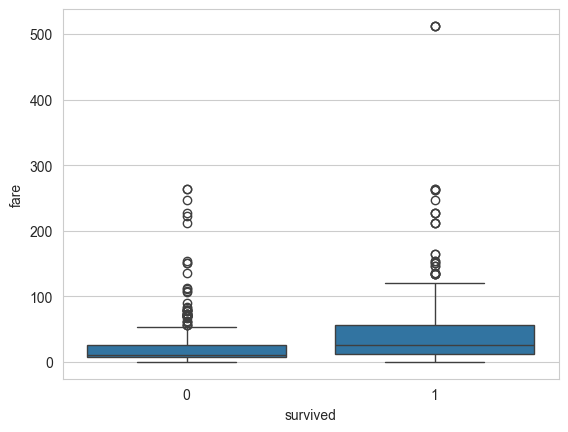

In [11]:
# TODO
df.groupby('survived')['fare'].mean()
sns.boxplot(x='survived', y='fare', data=df)
from scipy.stats import ttest_ind
g0 = df[df['survived']==0]['fare'].dropna()
g1 = df[df['survived']==1]['fare'].dropna()
stats.ttest_ind(g0, g1)

## Câu hỏi 4: Gia đình đông người có ảnh hưởng đến khả năng sống sót không?

<Axes: xlabel='family_size', ylabel='survived'>

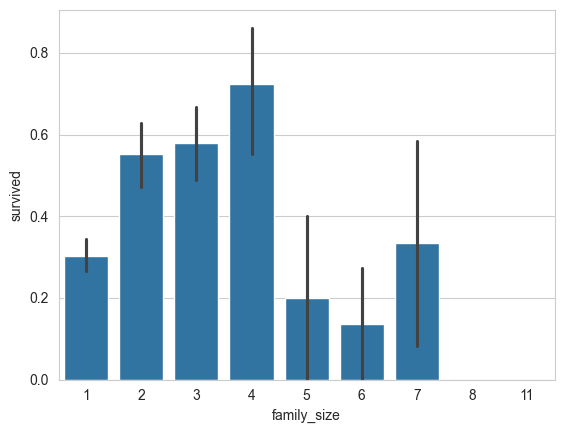

In [12]:
# TODO
df.groupby('family_size')['survived'].mean()
sns.barplot(x='family_size', y='survived', data=df)

## Câu hỏi 5: Cảng lên tàu (embark_town) nào có tỷ lệ sống sót cao nhất?

<Axes: xlabel='embark_town', ylabel='survived'>

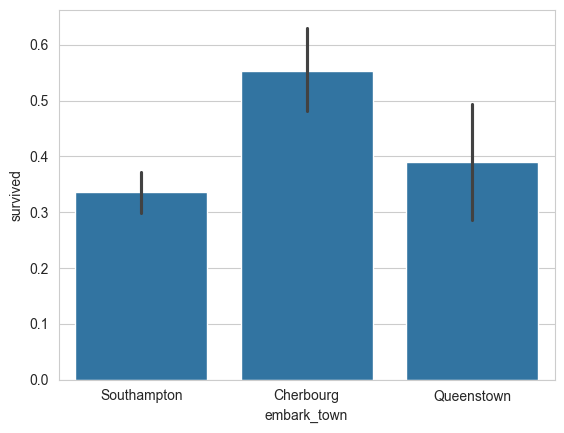

In [13]:
# TODO
df.groupby('embark_town')['survived'].mean().sort_values(ascending=False)
sns.barplot(x='embark_town', y='survived', data=df)

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể về dữ liệu Titanic.

Titanic có 891 hành khách, dữ liệu thiếu khá nhiều ở tuổi và tầng cabin. Giá vé chênh lệch rất lớn giữa các hành khách, một số ít người trả giá rất cao đẩy mức trung bình lên. Về sống sót, giới tính ảnh hưởng mạnh nhất — nữ sống sót cao hơn nam rõ rệt, hơn cả yếu tố hạng vé. Gia đình vừa (2-4 người) sống sót tốt hơn người đi một mình hoặc gia đình quá đông. Cảng lên tàu cũng có khác biệt nhưng có thể chỉ do liên quan đến hạng vé, chưa chắc là nguyên nhân trực tiếp.